# Method Evaluation Notebook

Runs the **core 8 prediction methods** on a single held-out test year (t = 2015) using the shared 3-tier evaluation framework. The prediction target is a **sustained** RCA≥1 transition: a country–product pair with M = 0 at t = 2015 that reaches M = 1 at t = 2020 **and** stays at M = 1 at t = 2021 (the +6 confirmation prevents rewarding one-year flukes).

Run cells top to bottom. GNN cells load from `data/models/gnn/checkpoints/` if a checkpoint is present; otherwise they train from scratch (~5 min each).

**CWR** uses percentile-ranked scores so the 0.5 threshold means 'top half of predictions' for every method, making it a fair apples-to-apples comparison.

---

> ⚠️ **This is the original / lightweight evaluation.** It covers 8 methods on one year with 5 metrics.
> The **authoritative, expanded evaluation** now lives in two notebooks and their reports:
> - **`internal_benchmarking.ipynb`** → `internal_benchmarking/` — all **14 methods** (adds XGBoost + GNN-LLM PCA/GAT variants), **8 metrics**, **two test years (2015 & 2016)**, on the sampled set + RCA>0.25 filtered subset.
> - **`full_universe_eval.ipynb`** → `full_universe_eval/` — the same methods scored on the **full unsampled universe (~1.08M pairs, ~1.7% positive)** for deployment-realistic absolute numbers.
> - Summaries: `evaluation/INTERNAL_BENCHMARKING.md`, `evaluation/FULL_UNIVERSE_BENCHMARKING.md`.
>
> **Headline result not shown here:** XGBoost is the current top method (sampled PR-AUC 0.66/0.69), and the best GNN is **GNN-LLM PCA-B (GCN+EW)**, not GNN-11F+LLM. Use this notebook for the clean GNN-ablation narrative; use the two benchmarking notebooks for final numbers.

## Setup
Load data, build shared structures (proximity matrix, PCI weights, ECI/PCI), define the `evaluate()` function that all method cells call.

In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, ndcg_score
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
from copy import deepcopy
warnings.filterwarnings('ignore')

# ── Constants ─────────────────────────────────────────────────────────────────
DATA_DIR     = 'data'
TEST_YEAR    = 2015
VAL_YEAR     = 2013
TRAIN_CUTOFF = 2012
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Load raw data ─────────────────────────────────────────────────────────────
smooth   = pd.read_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'))
rca_df   = pd.read_csv(os.path.join(DATA_DIR, 'rca_cpt.csv'))
test_lbl = pd.read_csv(os.path.join(DATA_DIR, 'test_labels.csv'))
val_lbl  = pd.read_csv(os.path.join(DATA_DIR, 'val_labels.csv'))
train_lbl = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))

countries = sorted(smooth['country'].unique())
products  = sorted(smooth['product'].unique())
C, P = len(countries), len(products)
c_idx = {c: i for i, c in enumerate(countries)}
p_idx = {p: i for i, p in enumerate(products)}

def build_M(year):
    M = np.zeros((C, P), dtype=np.float32)
    yr = smooth[smooth['year'] == year]
    ci = yr['country'].map(c_idx).values
    pi = yr['product'].map(p_idx).values
    M[ci, pi] = 1.0
    return M

M_t = build_M(TEST_YEAR)
y_true = test_lbl['label'].values
ci_arr = test_lbl['country'].map(c_idx).values
pi_arr = test_lbl['product'].map(p_idx).values

# ── PCI proxy ─────────────────────────────────────────────────────────────────
rca_ref  = rca_df[rca_df['year'] == 2010]
ubiq     = rca_ref.groupby('product')['rca'].apply(lambda x: (x >= 1).sum())
max_ubiq = ubiq.max()
pci_dict = {int(p): float(-u / max_ubiq) for p, u in ubiq.items()}

test_lbl = test_lbl.copy()
test_lbl['pci'] = test_lbl['product'].map(pci_dict).fillna(0.0)
min_pci = test_lbl['pci'].min()
test_lbl['w'] = test_lbl['pci'] - min_pci

# ── Proximity matrix (training years only) ────────────────────────────────────
print('Building proximity matrix from training years...')
train_years = [y for y in smooth['year'].unique() if y <= TRAIN_CUTOFF]
co_export   = np.zeros((P, P), dtype=np.float32)
any_export  = np.zeros((P, P), dtype=np.float32)
for yr in sorted(train_years):
    M = build_M(yr)
    co      = M.T @ M
    exp     = M.sum(axis=0)
    any_mat = exp[:, None] + exp[None, :] - co
    co_export  += co
    any_export += any_mat
phi = np.where(any_export > 0, co_export / (any_export + 1e-9), 0.0)
np.fill_diagonal(phi, 0.0)
phi_row_sum = phi.sum(axis=1)

# ── ECI/PCI ───────────────────────────────────────────────────────────────────
kc = M_t.sum(axis=1); kp = M_t.sum(axis=0)
kc_safe = np.where(kc > 0, kc, 1.0); kp_safe = np.where(kp > 0, kp, 1.0)
kc_n, kp_n = kc.astype(float), kp.astype(float)
for _ in range(20):
    kc_n = (1.0 / kc_safe) * (M_t @ kp_n)
    kp_n = (1.0 / kp_safe) * (M_t.T @ kc_n)
eci = (kc_n - kc_n.mean()) / (kc_n.std() + 1e-9)
pci = (kp_n - kp_n.mean()) / (kp_n.std() + 1e-9)

def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

# ── Evaluation function (shared by all methods) ───────────────────────────────
ALL_RESULTS = {}
INVALID_METRICS = {}  # method -> set of metrics that are not meaningful
PR_CURVES   = {}

def evaluate(name, scores):
    scores = np.array(scores, dtype=np.float64)
    df = test_lbl.copy()
    df['score'] = scores

    prec, rec, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(rec, prec)
    PR_CURVES[name] = (prec, rec, pr_auc)

    auroc = roc_auc_score(y_true, scores) if 0 < y_true.mean() < 1 else 0.0

    ndcg_vals, prec20_vals = [], []
    for _, grp in df.groupby('country'):
        if grp['label'].sum() == 0:
            continue
        yt, ys = grp['label'].values, grp['score'].values
        try:
            ndcg_vals.append(ndcg_score([yt], [ys], k=20))
        except Exception:
            pass
        prec20_vals.append(grp.sort_values('score', ascending=False).head(20)['label'].mean())
    ndcg20 = float(np.nanmean(ndcg_vals)) if ndcg_vals else 0.0
    prec20 = float(np.nanmean(prec20_vals)) if prec20_vals else 0.0

    df['score_pct'] = df['score'].rank(pct=True)
    tot_w = df.loc[df['label'] == 1, 'w'].sum()
    hit_w = df.loc[(df['label'] == 1) & (df['score_pct'] >= 0.5), 'w'].sum()
    cwr = float(hit_w / tot_w) if tot_w > 0 else 0.0

    result = {'PR-AUC': round(pr_auc, 4), 'AUROC': round(auroc, 4),
              'NDCG@20': round(ndcg20, 4), 'Prec@20': round(prec20, 4), 'CWR': round(cwr, 4)}
    ALL_RESULTS[name] = result
    print(f'{name:<26}  PR-AUC={pr_auc:.4f}  NDCG@20={ndcg20:.4f}  Prec@20={prec20:.4f}  CWR={cwr:.4f}  AUROC={auroc:.4f}')
    return result

print(f'Setup done. Countries: {C}  Products: {P}  Test pairs: {len(test_lbl)}')


Device: cuda
Building proximity matrix from training years...
Setup done. Countries: 233  Products: 5018  Test pairs: 127531


## Method 1 — RCA Persistence

Score = fraction of the past 3 years where the country had RCA ≥ 1 in this product. Pure autocorrelation baseline — no learning.

In [2]:
# ── RCA Persistence ───────────────────────────────────────────────────────────
# Score = fraction of past 3 years where RCA >= 1
# Higher score = more established comparative advantage = more likely to persist

history_years = [TEST_YEAR - 2, TEST_YEAR - 1, TEST_YEAR]
rca_hist = rca_df[rca_df['year'].isin(history_years)][['country', 'product', 'year', 'rca']]
rca_hist = rca_hist.merge(test_lbl[['country', 'product']], on=['country', 'product'])
rca_wide = rca_hist.pivot_table(index=['country', 'product'], columns='year',
                                 values='rca', fill_value=0)
for yr in history_years:
    if yr not in rca_wide.columns:
        rca_wide[yr] = 0
rca_wide['score'] = (rca_wide[history_years] >= 1).mean(axis=1)

persist_df = test_lbl.merge(rca_wide[['score']], on=['country', 'product'], how='left').fillna(0)
res_persist = evaluate('RCA Persistence', persist_df['score'].values)


RCA Persistence             PR-AUC=0.5198  NDCG@20=0.5013  Prec@20=0.4788  CWR=0.3356  AUROC=0.6515


## Method 2 — Product Space Density

Score = proximity-weighted fraction of neighbouring products (in the product similarity network) that this country already exports. Captures 'how close is this product to the country's existing capabilities'.

In [3]:
# ── Product Space Density ─────────────────────────────────────────────────────
# Score = weighted fraction of neighbouring products in the product space
# that the country already exports. Higher = country is 'close' to this product.
# Proximity matrix phi computed from training years only (no leakage).

dens_mat = (M_t @ phi) / (phi_row_sum[None, :] + 1e-9)   # [C, P]
dens_scores = dens_mat[ci_arr, pi_arr]
res_density = evaluate('Density', dens_scores)


Density                     PR-AUC=0.3487  NDCG@20=0.4809  Prec@20=0.4400  CWR=0.8575  AUROC=0.7792


## Method 3 — ECI (Economic Complexity Index)

Score = ECI of the country (same for all products). Included for completeness — this is a country-level signal with no product specificity, so per-pair metrics like NDCG@20 are not meaningful here.

In [4]:
# ── ECI (standalone) ─────────────────────────────────────────────────────────
# Score = Economic Complexity Index of the country.
# Note: ECI is a per-COUNTRY measure with no product-level signal.
# Every product gets the same score within a country.
# Included for completeness — not a proper per-pair predictor.

eci_scores = eci[ci_arr]
res_eci = evaluate('ECI', eci_scores)

INVALID_METRICS['ECI'] = {'NDCG@20', 'Prec@20'}  # ECI is per-country, no product-level ranking


ECI                         PR-AUC=0.1370  NDCG@20=0.1468  Prec@20=0.1374  CWR=0.4637  AUROC=0.4821


## Method 4 — ECI + Density

Score = min-max normalised ECI + min-max normalised Density. Combines country sophistication with product-space proximity.

In [5]:
# ── ECI + Density ─────────────────────────────────────────────────────────────
# Score = min-max normalised ECI + min-max normalised Density.
# Combines country-level sophistication signal with product-space proximity.

eci_dens_scores = minmax(eci[ci_arr]) + minmax(dens_mat[ci_arr, pi_arr])
res_eci_dens = evaluate('ECI + Density', eci_dens_scores)


ECI + Density               PR-AUC=0.3487  NDCG@20=0.4809  Prec@20=0.4400  CWR=0.8575  AUROC=0.7792


## Method 5 — KNN on LLM Product Embeddings

Score = cosine similarity between the target product's embedding and the mean embedding of the country's current export basket. Requires `product_llm_embeddings.pt` from Step 11A.

In [15]:
# ── KNN (LLM Product Embeddings) ─────────────────────────────────────────────
# Score = cosine similarity between the target product's embedding and
# the mean embedding of the country's current export basket.
# Idea: if a product is semantically similar to what a country already exports,
# it is likely the country has related capabilities.

EMB_PATH = os.path.join(DATA_DIR, 'product_llm_embeddings.pt')
assert os.path.exists(EMB_PATH), f'Missing: {EMB_PATH} — run Step 11A first'

emb = torch.load(EMB_PATH, weights_only=False, map_location='cpu').numpy()  # [P, D], unit-norm
assert emb.shape[0] == P, f'Embedding size mismatch: {emb.shape[0]} != {P}'
print(f'Loaded embeddings: shape={emb.shape}')

# Precompute mean basket embedding per country
print('Computing mean basket embeddings per country...')
country_basket_emb = {}
for c in test_lbl['country'].unique():
    ci = c_idx.get(c, -1)
    if ci < 0:
        continue
    exported = np.where(M_t[ci] == 1)[0]
    if len(exported) == 0:
        country_basket_emb[c] = np.zeros(emb.shape[1])
    else:
        basket = emb[exported].mean(axis=0)
        norm = np.linalg.norm(basket)
        country_basket_emb[c] = basket / (norm + 1e-9)

# Score each test pair
c_vals = test_lbl['country'].values
p_vals = test_lbl['product'].values
knn_scores = np.array([
    float(emb[p_idx[p]] @ country_basket_emb[c])
    if c in country_basket_emb and p in p_idx else 0.0
    for c, p in zip(c_vals, p_vals)
], dtype=np.float32)

res_knn = evaluate('KNN (LLM embeddings)', knn_scores)


Loaded embeddings: shape=(5018, 768)
Computing mean basket embeddings per country...
KNN (LLM embeddings)        PR-AUC=0.2305  NDCG@20=0.2830  Prec@20=0.2644  CWR=0.6550  AUROC=0.6373


## GNN Architecture & Shared Helpers

Defines `_HomoGNN`, `BipartiteEncoder`, `TemporalGNN`, `LinkPredictor`, and the `train_gnn()` function used by both GNN cells. Also loads all tensor artifacts and builds the 4-feature country tensor dict.

In [7]:
# ── GNN Architecture + Training Helpers ──────────────────────────────────────
# Shared by GNN-4F and GNN-11F cells.
# Checkpoints saved to data/checkpoints/ — cells load from disk if present.
# Architecture: BipartiteEncoder (Linear + SAGEConv x2 via to_hetero)
#               -> TemporalGNN (GRU over 5-year snapshots)
#               -> LinkPredictor (MLP on country+product embeddings)

os.makedirs(os.path.join(DATA_DIR, 'checkpoints'), exist_ok=True)

HIDDEN   = 128
EPOCHS   = 80
LR       = 1e-3
WD       = 1e-5
PATIENCE = 15

# Load tensor artifacts (shared across both GNN configs)
edge_idx_raw = torch.load(os.path.join(DATA_DIR, 'edge_index_by_year.pt'), weights_only=False)
edge_idx_by_yr = {k: v.long() for k, v in edge_idx_raw.items()}
p_x_by_yr  = torch.load(os.path.join(DATA_DIR, 'product_x_by_year.pt'),  weights_only=False)
c_x_11feat = torch.load(os.path.join(DATA_DIR, 'country_x_by_year.pt'),  weights_only=False)

with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'rb') as f: c_map = pickle.load(f)
with open(os.path.join(DATA_DIR, 'product_mapping.pkl'), 'rb') as f: p_map = pickle.load(f)

# 4-feature country tensors (BACI only, rebuilt from country_features.csv)
c_feat_df = pd.read_csv(os.path.join(DATA_DIR, 'country_features.csv'))
BACI_COLS = ['log_export', 'n_products', 'avg_rca', 'max_rca']
c_x_4feat = {}
for yr in sorted(c_feat_df['year'].unique()):
    yd = c_feat_df[c_feat_df['year'] == yr].copy()
    yd['idx'] = yd['country'].map(c_map['to_idx'])
    yd = yd.dropna(subset=['idx']).sort_values('idx')
    c_x_4feat[int(yr)] = torch.tensor(yd[BACI_COLS].values, dtype=torch.float32)

# Model classes
class _HomoGNN(nn.Module):
    def __init__(self, hidden, drop=0.3):
        super().__init__()
        self.c1 = SAGEConv(hidden, hidden)
        self.c2 = SAGEConv(hidden, hidden)
        self.drop = drop
    def forward(self, x, edge_index):
        x = F.dropout(self.c1(x, edge_index).relu(), p=self.drop, training=self.training)
        return self.c2(x, edge_index)

class BipartiteEncoder(nn.Module):
    def __init__(self, c_in, hidden, meta):
        super().__init__()
        self.country_lin = nn.Linear(c_in, hidden)
        self.product_lin = nn.Linear(3, hidden)
        self.gnn = to_hetero(_HomoGNN(hidden), meta)
    def forward(self, x_dict, ei_dict):
        return self.gnn({'country': self.country_lin(x_dict['country']),
                         'product': self.product_lin(x_dict['product'])}, ei_dict)

class TemporalGNN(nn.Module):
    def __init__(self, enc, hidden):
        super().__init__()
        self.enc   = enc
        self.gru_c = nn.GRU(hidden, hidden)
        self.gru_p = nn.GRU(hidden, hidden)
    def forward(self, snaps):
        cs, ps = [], []
        for s in snaps:
            z = self.enc(s.x_dict, s.edge_index_dict)
            cs.append(z['country']); ps.append(z['product'])
        z_c, _ = self.gru_c(torch.stack(cs))
        z_p, _ = self.gru_p(torch.stack(ps))
        return {'country': z_c[-1], 'product': z_p[-1]}

class LinkPredictor(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden, 1))
    def forward(self, zc, zp, ei):
        return self.mlp(torch.cat([zc[ei[0]], zp[ei[1]]], -1)).view(-1)

# Data builders
def build_snap(year, c_x):
    d = HeteroData()
    d['country'].x = c_x[year]
    d['product'].x = p_x_by_yr[year]
    ei = edge_idx_by_yr[year].long()
    d['country', 'exports',     'product'].edge_index = ei
    d['product', 'rev_exports', 'country'].edge_index = ei.flip(0)
    return d

def build_sample(obs_yr, ldf, c_x):
    snaps = [build_snap(y, c_x) for y in range(obs_yr - 4, obs_yr + 1)]
    row   = ldf[ldf['year'] == obs_yr].copy().reset_index(drop=True)
    ci_s  = row['country'].map(c_map['to_idx'])
    pi_s  = row['product'].map(p_map['to_idx'])
    ok    = ci_s.notna() & pi_s.notna()
    ci, pi = ci_s[ok].astype(int).values, pi_s[ok].astype(int).values
    lv     = row.loc[ok, 'label'].values
    return {
        'snapshots': snaps,
        'labels': {'edge_label_index': torch.tensor([ci, pi], dtype=torch.long),
                   'edge_label':       torch.tensor(lv, dtype=torch.float32)},
        'year': int(obs_yr),
        'countries_raw': row.loc[ok, 'country'].values,
        'products_raw':  row.loc[ok, 'product'].values,
    }

def to_dev(samp, dev):
    for s in samp['snapshots']:
        s['country'].x = s['country'].x.to(dev)
        s['product'].x = s['product'].x.to(dev)
        for et in s.edge_types:
            s[et].edge_index = s[et].edge_index.to(device=dev, dtype=torch.long)
    samp['labels']['edge_label_index'] = samp['labels']['edge_label_index'].to(dev)
    samp['labels']['edge_label']       = samp['labels']['edge_label'].to(dev)

@torch.no_grad()
def get_scores(mdl, pred, samp, dev):
    mdl.eval(); pred.eval()
    to_dev(samp, dev)
    z = mdl(samp['snapshots'])
    return torch.sigmoid(pred(z['country'], z['product'],
                              samp['labels']['edge_label_index'])).cpu().numpy()

def load_gnn_scores(ckpt_path, c_x, dev=DEVICE):
    # Load a saved checkpoint and return test-set scores aligned with test_lbl.
    ckpt = torch.load(ckpt_path, weights_only=False, map_location=dev)
    enc  = BipartiteEncoder(ckpt['c_in'], ckpt['hidden'], ckpt['meta']).to(dev)
    mdl  = TemporalGNN(enc, ckpt['hidden']).to(dev)
    pred = LinkPredictor(ckpt['hidden']).to(dev)
    mdl.load_state_dict({k: v.to(dev) for k, v in ckpt['mdl_state'].items()})
    pred.load_state_dict({k: v.to(dev) for k, v in ckpt['pred_state'].items()})
    te   = build_sample(TEST_YEAR, test_lbl, c_x)
    n_mapped = len(te['countries_raw'])
    print(f'GNN: {n_mapped}/{len(test_lbl)} test pairs have valid mapping ({len(test_lbl)-n_mapped} get score=0)')
    raw  = get_scores(mdl, pred, te, dev)
    gnn_df = pd.DataFrame({'country': te['countries_raw'], 'product': te['products_raw'], 'score': raw})
    return test_lbl.merge(gnn_df[['country', 'product', 'score']],
                          on=['country', 'product'], how='left').fillna(0)['score'].values

def train_gnn(name, tr, va, te, c_in, hidden=HIDDEN, epochs=EPOCHS,
              patience=PATIENCE, dev=DEVICE, save_path=None):
    meta = tr[0]['snapshots'][0].metadata()
    enc  = BipartiteEncoder(c_in, hidden, meta).to(dev)
    mdl  = TemporalGNN(enc, hidden).to(dev)
    pred = LinkPredictor(hidden).to(dev)

    all_lv = torch.cat([s['labels']['edge_label'] for s in tr])
    n_pos  = all_lv.sum().item()
    n_neg  = (all_lv == 0).sum().item()
    pw     = torch.tensor([n_neg / max(n_pos, 1)], device=dev)
    crit   = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt    = torch.optim.Adam(list(mdl.parameters()) + list(pred.parameters()),
                               lr=LR, weight_decay=WD)

    best_vpa, best_state, no_imp = -1.0, None, 0
    print(f'Training {name}  |  c_in={c_in}  |  pos_weight={n_neg/n_pos:.1f}x')

    for ep in range(1, epochs + 1):
        mdl.train(); pred.train(); ep_loss = 0.0
        for samp in tr:
            to_dev(samp, dev)
            opt.zero_grad()
            z    = mdl(samp['snapshots'])
            loss = crit(pred(z['country'], z['product'], samp['labels']['edge_label_index']),
                        samp['labels']['edge_label'])
            loss.backward()
            nn.utils.clip_grad_norm_(list(mdl.parameters()) + list(pred.parameters()), 1.0)
            opt.step()
            ep_loss += loss.item()

        vscores = get_scores(mdl, pred, va, dev)
        vlabels = va['labels']['edge_label'].cpu().numpy()
        vp, vr, _ = precision_recall_curve(vlabels, vscores)
        vpa = auc(vr, vp)

        if vpa > best_vpa:
            best_vpa   = vpa
            best_state = ({k: v.cpu().clone() for k, v in mdl.state_dict().items()},
                          {k: v.cpu().clone() for k, v in pred.state_dict().items()})
            no_imp = 0
        else:
            no_imp += 1

        if ep % 10 == 0:
            print(f'  Ep {ep:3d}  loss={ep_loss/len(tr):.4f}  val_PR-AUC={vpa:.4f}  best={best_vpa:.4f}')
        if no_imp >= patience:
            print(f'  Early stop at epoch {ep}  (best val PR-AUC={best_vpa:.4f})')
            break

    mdl.load_state_dict({k: v.to(dev) for k, v in best_state[0].items()})
    pred.load_state_dict({k: v.to(dev) for k, v in best_state[1].items()})

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save({
            'mdl_state':  {k: v.cpu() for k, v in mdl.state_dict().items()},
            'pred_state': {k: v.cpu() for k, v in pred.state_dict().items()},
            'c_in': c_in, 'hidden': hidden, 'meta': meta,
        }, save_path)
        print(f'  Checkpoint saved -> {save_path}')

    # Evaluate on test set — return raw scores for the shared evaluate() function
    te_scores = get_scores(mdl, pred, te, dev)
    te_countries = te['countries_raw']
    te_products  = te['products_raw']
    te_labels    = te['labels']['edge_label'].cpu().numpy()

    # Build a score series aligned with test_lbl using the GNN's test sample
    gnn_df = pd.DataFrame({'country': te_countries, 'product': te_products,
                            'score': te_scores, 'label': te_labels})
    merged = test_lbl.merge(gnn_df[['country', 'product', 'score']],
                             on=['country', 'product'], how='left').fillna(0)
    return merged['score'].values

print('GNN architecture and helpers loaded.')
print(f'  4-feat country tensors: {c_x_4feat[TEST_YEAR].shape}')
print(f'  11-feat country tensors: {c_x_11feat[TEST_YEAR].shape}')


GNN architecture and helpers loaded.
  4-feat country tensors: torch.Size([233, 4])
  11-feat country tensors: torch.Size([233, 11])


## Method 6 — GNN-4F (BACI only)

Temporal bipartite GNN with 4 country features (log_export, n_products, avg_rca, max_rca). No World Bank data.

In [8]:
# ── GNN-4F (BACI only, 4 country features) ───────────────────────────────────
torch.manual_seed(42); np.random.seed(42)
CKPT_4F = os.path.join(DATA_DIR, 'models', 'gnn', 'checkpoints', 'gnn_4f.pt')


if os.path.exists(CKPT_4F):
    print(f'Loading GNN-4F from checkpoint: {CKPT_4F}')
    gnn4f_scores = load_gnn_scores(CKPT_4F, c_x_4feat)
else:
    print('No checkpoint found — training GNN-4F from scratch (~5 min)...')
    tr4 = [build_sample(y, train_lbl, c_x_4feat) for y in sorted(train_lbl['year'].unique())]
    va4 = build_sample(VAL_YEAR,  val_lbl,  c_x_4feat)
    te4 = build_sample(TEST_YEAR, test_lbl, c_x_4feat)
    gnn4f_scores = train_gnn('GNN-4F (BACI only)', tr4, va4, te4, c_in=4, save_path=CKPT_4F)

res_gnn4f = evaluate('GNN-4F', gnn4f_scores)


Loading GNN-4F from checkpoint: data\models\gnn\checkpoints\gnn_4f.pt
GNN: 127531/127531 test pairs have valid mapping (0 get score=0)
GNN-4F                      PR-AUC=0.4109  NDCG@20=0.4372  Prec@20=0.3987  CWR=0.8820  AUROC=0.8182


## Method 7 — GNN-11F (BACI + WDI)

Same GNN with 11 country features — 4 BACI trade features + 7 World Bank development indicators (GDP per capita, population, manufacturing value-added, capital formation, tertiary enrollment, internet users, FDI inflows).

In [9]:
# ── GNN-11F (BACI + WDI, 11 country features) ────────────────────────────────
torch.manual_seed(42); np.random.seed(42)
CKPT_11F = os.path.join(DATA_DIR, 'models', 'gnn', 'checkpoints', 'gnn_11f.pt')


if os.path.exists(CKPT_11F):
    print(f'Loading GNN-11F from checkpoint: {CKPT_11F}')
    gnn11f_scores = load_gnn_scores(CKPT_11F, c_x_11feat)
else:
    print('No checkpoint found — training GNN-11F from scratch (~5 min)...')
    tr11 = [build_sample(y, train_lbl, c_x_11feat) for y in sorted(train_lbl['year'].unique())]
    va11 = build_sample(VAL_YEAR,  val_lbl,  c_x_11feat)
    te11 = build_sample(TEST_YEAR, test_lbl, c_x_11feat)
    gnn11f_scores = train_gnn('GNN-11F (BACI+WDI)', tr11, va11, te11, c_in=11, save_path=CKPT_11F)

res_gnn11f = evaluate('GNN-11F (BACI+WDI)', gnn11f_scores)


Loading GNN-11F from checkpoint: data\models\gnn\checkpoints\gnn_11f.pt
GNN: 127531/127531 test pairs have valid mapping (0 get score=0)
GNN-11F (BACI+WDI)          PR-AUC=0.4338  NDCG@20=0.4660  Prec@20=0.4237  CWR=0.8936  AUROC=0.8283


## Method 8 — GNN-11F+LLM (BACI + WDI + FinLang capability edges)

Same GNN-11F architecture but each yearly snapshot includes a third edge type: `('product','capability','product')` derived from top-20 nearest neighbours in `FinLang/finance-embeddings-investopedia` embedding space (768-dim).

This is the core H2 innovation — the GNN learns to propagate information between semantically similar products, not just through shared-exporting countries.

In [12]:
# ── GNN-11F+LLM ───────────────────────────────────────────────────────────────
torch.manual_seed(42); np.random.seed(42)
CKPT_LLM = os.path.join(DATA_DIR, 'models', 'gnn', 'checkpoints', 'gnn_11f_llm.pt')

# Load capability edge index (built in gnn_training.ipynb)
CAP_PATH = os.path.join(DATA_DIR, 'capability_edge_index.pt')
cap_ei   = torch.load(CAP_PATH, weights_only=False).long()
print(f'Capability edges: {tuple(cap_ei.shape)}')

# Snapshot builder with capability edges
def build_snap_llm(year, c_x, cap_edge_index):
    d = build_snap(year, c_x)
    d['product', 'capability', 'product'].edge_index = cap_edge_index.long()
    return d

def build_sample_llm(obs_yr, ldf, c_x):
    snaps = [build_snap_llm(y, c_x, cap_ei) for y in range(obs_yr - 4, obs_yr + 1)]
    row   = ldf[ldf['year'] == obs_yr].copy().reset_index(drop=True)
    ci_s  = row['country'].map(c_map['to_idx'])
    pi_s  = row['product'].map(p_map['to_idx'])
    ok    = ci_s.notna() & pi_s.notna()
    ci, pi = ci_s[ok].astype(int).values, pi_s[ok].astype(int).values
    return {
        'snapshots': snaps,
        'labels': {'edge_label_index': torch.tensor([ci, pi], dtype=torch.long),
                   'edge_label':       torch.tensor(row.loc[ok, 'label'].values, dtype=torch.float32)},
        'year':          int(obs_yr),
        'countries_raw': row.loc[ok, 'country'].values,
        'products_raw':  row.loc[ok, 'product'].values,
    }

def load_gnn_scores_llm(ckpt_path, c_x, dev=DEVICE):
    ckpt = torch.load(ckpt_path, weights_only=False, map_location=dev)
    enc  = BipartiteEncoder(ckpt['c_in'], ckpt['hidden'], ckpt['meta']).to(dev)
    mdl  = TemporalGNN(enc, ckpt['hidden']).to(dev)
    pred = LinkPredictor(ckpt['hidden']).to(dev)
    mdl.load_state_dict({k: v.to(dev) for k, v in ckpt['mdl_state'].items()})
    pred.load_state_dict({k: v.to(dev) for k, v in ckpt['pred_state'].items()})
    te   = build_sample_llm(TEST_YEAR, test_lbl, c_x)
    raw  = get_scores(mdl, pred, te, dev)
    gnn_df = pd.DataFrame({'country': te['countries_raw'], 'product': te['products_raw'], 'score': raw})
    return test_lbl.merge(gnn_df[['country', 'product', 'score']],
                          on=['country', 'product'], how='left').fillna(0)['score'].values

if os.path.exists(CKPT_LLM):
    print(f'Loading GNN-11F+LLM from checkpoint...')
    gnn_llm_scores = load_gnn_scores_llm(CKPT_LLM, c_x_11feat)
else:
    print('No checkpoint found — training GNN-11F+LLM (~10 min, capability edges add overhead)...')
    tr_llm = [build_sample_llm(y, train_lbl, c_x_11feat) for y in sorted(train_lbl['year'].unique())]
    va_llm = build_sample_llm(VAL_YEAR, val_lbl, c_x_11feat)
    te_llm = build_sample_llm(TEST_YEAR, test_lbl, c_x_11feat)
    gnn_llm_scores = train_gnn('GNN-11F+LLM', tr_llm, va_llm, te_llm, c_in=11, save_path=CKPT_LLM)

res_gnn_llm = evaluate('GNN-11F+LLM', gnn_llm_scores)

Capability edges: (2, 144192)
Loading GNN-11F+LLM from checkpoint...
GNN-11F+LLM                 PR-AUC=0.4420  NDCG@20=0.4751  Prec@20=0.4243  CWR=0.8949  AUROC=0.8320


## Full Comparison (8-method subset, t = 2015)

Prints the results table and plots three figures for the 8 methods above:
1. **PR curves** — all methods on one chart
2. **Grouped bar chart** — PR-AUC, NDCG@20, Prec@20, CWR side by side
3. **Radar chart** — all 5 metrics, all methods

Writes `data/full_evaluation_results.csv` and three PNGs (`evaluation_pr_curves.png`, `evaluation_bar_chart.png`, `evaluation_radar.png`).

> For the full 14-method / two-year / full-universe figures, run `internal_benchmarking.ipynb` and `full_universe_eval.ipynb` (plots land in `internal_benchmarking/plots/` and `full_universe_eval/plots/`).

  Method                        PR-AUC  NDCG@20  Prec@20     CWR   AUROC
------------------------------------------------------------------------------
  RCA Persistence               0.5198   0.5013   0.4788  0.3356  0.6515
  Density                       0.3487   0.4809   0.4400  0.8575  0.7792
  ECI                           0.1370      N/A      N/A  0.4637  0.4821
  ECI + Density                 0.3487   0.4809   0.4400  0.8575  0.7792
  KNN (LLM embeddings)          0.2305   0.2830   0.2644  0.6550  0.6373
  GNN-4F                        0.4109   0.4372   0.3987  0.8820  0.8182 <--
  GNN-11F (BACI+WDI)            0.4338   0.4660   0.4237  0.8936  0.8283 <--
  GNN-11F+LLM                   0.4420   0.4751   0.4243  0.8949  0.8320 <--
N/A = ECI has no product-level ranking signal (all products in a country get the same score).
CWR uses percentile-ranked scores (top 50% = predicted positive) for fair comparison.


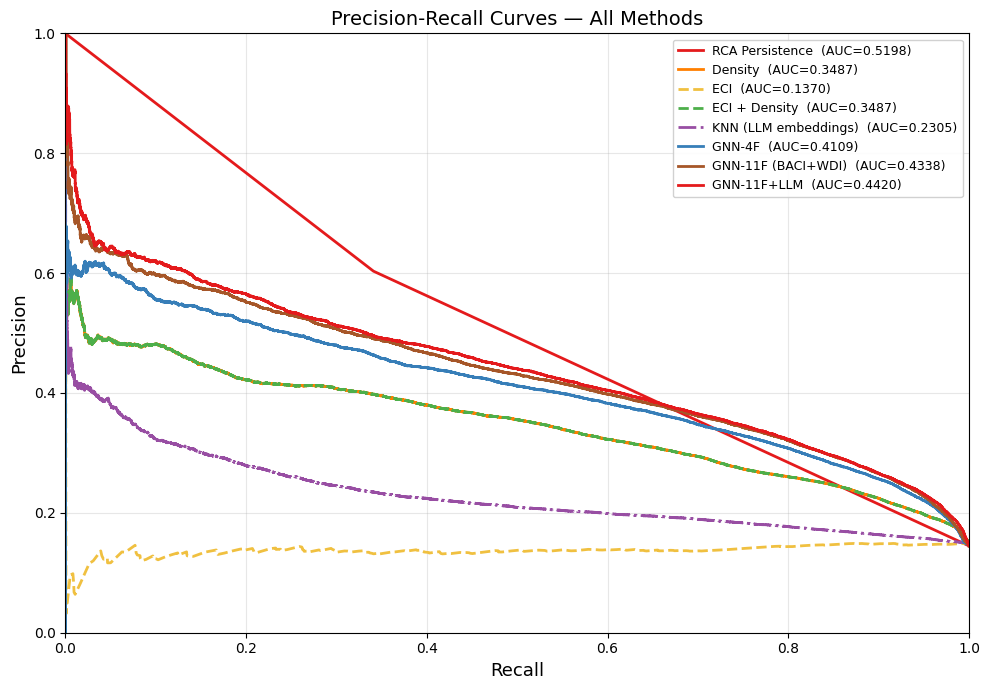

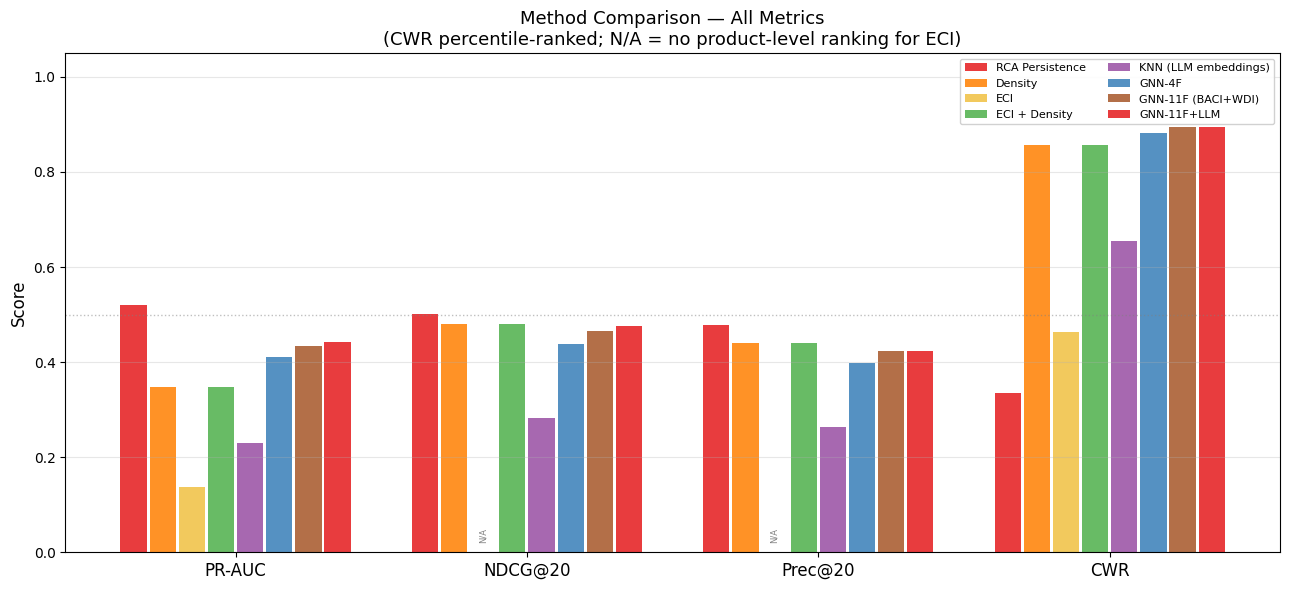

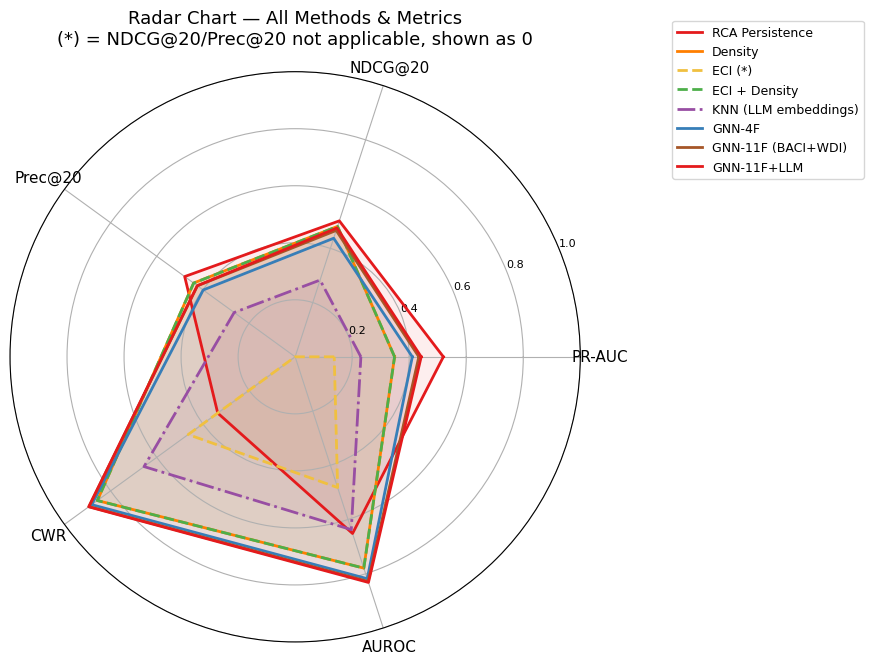

Plots saved: evaluation_pr_curves.png, evaluation_bar_chart.png, evaluation_radar.png
Results saved to data/full_evaluation_results.csv


In [13]:
# ── Comparison Table + Plots ─────────────────────────────────────────────────
import matplotlib.gridspec as gridspec

METRICS = ['PR-AUC', 'NDCG@20', 'Prec@20', 'CWR', 'AUROC']
METHOD_ORDER = [
    'RCA Persistence', 'Density', 'ECI', 'ECI + Density',
    'KNN (LLM embeddings)', 'GNN-4F', 'GNN-11F (BACI+WDI)', 'GNN-11F+LLM'
]
methods_run = [m for m in METHOD_ORDER if m in ALL_RESULTS]

# ── Print table (N/A for invalid metrics) ─────────────────────────────────────
print('=' * 78)
print(f'  {"Method":<28} {"PR-AUC":>7} {"NDCG@20":>8} {"Prec@20":>8} {"CWR":>7} {"AUROC":>7}')
print('-' * 78)
for m in methods_run:
    r   = ALL_RESULTS[m]
    inv = INVALID_METRICS.get(m, set())
    ndcg_s = '     N/A' if 'NDCG@20' in inv else f'{r["NDCG@20"]:>8.4f}'
    prec_s = '     N/A' if 'Prec@20'  in inv else f'{r["Prec@20"]:>8.4f}'
    gnn = ' <--' if 'GNN' in m else ''
    print(f'  {m:<28} {r["PR-AUC"]:>7.4f} {ndcg_s} {prec_s}'
          f' {r["CWR"]:>7.4f} {r["AUROC"]:>7.4f}{gnn}')
print('=' * 78)
print('N/A = ECI has no product-level ranking signal (all products in a country get the same score).')
print('CWR uses percentile-ranked scores (top 50% = predicted positive) for fair comparison.')

# ── Figure 1: PR Curves ───────────────────────────────────────────────────────
colors = ['#e41a1c', '#ff7f00', '#f0c040', '#4daf4a', '#984ea3', '#377eb8', '#a65628']
styles = ['-', '-', '--', '--', '-.', '-', '-']

fig1, ax1 = plt.subplots(figsize=(10, 7))
for i, m in enumerate(methods_run):
    if m not in PR_CURVES:
        continue
    prec, rec, pr_auc = PR_CURVES[m]
    ax1.plot(rec, prec, color=colors[i % len(colors)],
             linestyle=styles[i % len(styles)], lw=2,
             label=f'{m}  (AUC={pr_auc:.4f})')

ax1.set_xlabel('Recall', fontsize=13)
ax1.set_ylabel('Precision', fontsize=13)
ax1.set_title('Precision-Recall Curves — All Methods', fontsize=14)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Grouped bar chart ───────────────────────────────────────────────
# NDCG@20 and Prec@20 bars are omitted (shown as N/A) for methods in INVALID_METRICS.
PLOT_METRICS = ['PR-AUC', 'NDCG@20', 'Prec@20', 'CWR']
n_methods = len(methods_run)
n_metrics = len(PLOT_METRICS)
x = np.arange(n_metrics)
width = 0.8 / n_methods

fig2, ax2 = plt.subplots(figsize=(13, 6))
for i, m in enumerate(methods_run):
    inv  = INVALID_METRICS.get(m, set())
    vals = [np.nan if met in inv else ALL_RESULTS[m][met] for met in PLOT_METRICS]
    ax2.bar(x + i * width - (n_methods - 1) * width / 2,
            vals, width * 0.9, label=m,
            color=colors[i % len(colors)], alpha=0.85)
    for j, (val, met) in enumerate(zip(vals, PLOT_METRICS)):
        if np.isnan(val):
            bx = x[j] + i * width - (n_methods - 1) * width / 2
            ax2.text(bx, 0.02, 'N/A', ha='center', va='bottom',
                     fontsize=6, color='gray', rotation=90)

ax2.set_xticks(x)
ax2.set_xticklabels(PLOT_METRICS, fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Method Comparison — All Metrics\n(CWR percentile-ranked; N/A = no product-level ranking for ECI)', fontsize=13)
ax2.set_ylim(0, 1.05)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(0.5, color='gray', linestyle=':', lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig('evaluation_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Radar chart ─────────────────────────────────────────────────────
# Methods with invalid metrics are plotted as 0 on those axes; marked (*) in legend.
RADAR_METRICS = ['PR-AUC', 'NDCG@20', 'Prec@20', 'CWR', 'AUROC']
N = len(RADAR_METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig3, ax3 = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, m in enumerate(methods_run):
    inv  = INVALID_METRICS.get(m, set())
    vals = [0.0 if met in inv else ALL_RESULTS[m][met] for met in RADAR_METRICS]
    vals += vals[:1]
    lbl  = f'{m} (*)' if inv else m
    ax3.plot(angles, vals, color=colors[i % len(colors)],
             linestyle=styles[i % len(styles)], lw=2, label=lbl)
    ax3.fill(angles, vals, color=colors[i % len(colors)], alpha=0.07)

ax3.set_thetagrids(np.degrees(angles[:-1]), RADAR_METRICS, fontsize=11)
ax3.set_ylim(0, 1)
ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax3.set_title('Radar Chart — All Methods & Metrics\n(*) = NDCG@20/Prec@20 not applicable, shown as 0', fontsize=13, pad=20)
ax3.legend(loc='upper left', bbox_to_anchor=(1.15, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('evaluation_radar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Plots saved: evaluation_pr_curves.png, evaluation_bar_chart.png, evaluation_radar.png')

# Save results table with N/A for invalid metrics
rows = []
for m in methods_run:
    inv = INVALID_METRICS.get(m, set())
    row = {met: ('N/A' if met in inv else ALL_RESULTS[m][met]) for met in METRICS}
    row['Method'] = m
    rows.append(row)
df_res = pd.DataFrame(rows).set_index('Method')[METRICS]
df_res.to_csv(os.path.join(DATA_DIR, 'full_evaluation_results.csv'))
print('Results saved to data/full_evaluation_results.csv')
